# Notebook 2: Satınalma Qabiliyyəti Analizi (2019–2024)
**Mənbələr:**
- Nominal əmək haqqı: Dövlət Statistika Komitəsi (stat.gov.az), CEIC
- CPI: World Bank WDI / Macrotrends / IMF
- 2025–2026 datası mövcud deyil — bu notebook-da istifadə edilmir

**Düzəlişlər:**
- Köhnə: `nominal_wage_azn` 2019=635 idi — DSK rəsmi 2019 ortalama: ~637 AZN (düzgün)
- Köhnə: 2021 əmək haqqı 732 idi — DSK/CEIC: 728.5 AZN (H1 2021 rəqəmi)
- Köhnə: 2022 əmək haqqı 839 idi — DSK: ~840 AZN (düzgün)
- Köhnə: 2023 əmək haqqı 923 idi — DSK rəsmi: ~933 AZN (düzəldildi)
- Köhnə: 2024 əmək haqqı 1000 idi — CEIC: ~1040 AZN (düzəldildi)
- Köhnə: CPI 2022 = 13.9 idi — WB rəsmi: 13.85% (kiçik dəqiqlik fərqi)
- Köhnə: CPI 2024 = 4.9 idi — IMF/Worlddata: 2.1% (böyük xəta — düzəldildi)
- Köhnə: 2025–2026 ÜDM PPP uydurmadır — silindi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11


In [2]:
# ── REAL DATA — yalnız 2019–2024 ────────────────────────────────────────────
# nominal_wage_azn: DSK / CEIC (stat.gov.az labour market reports)
# cpi_inflation_pct: World Bank WDI + IMF (macrotrends.net verification)
# gdp_per_capita_ppp: World Bank WDI (NY.GDP.PCAP.PP.CD) — PPP, int. $

data = {
    'year':               [2019,   2020,   2021,   2022,   2023,   2024],
    # DSK rəsmi illik ortalama nominal əmək haqqı (AZN/ay)
    'nominal_wage_azn':   [637,    700,    729,    840,    934,    1040],
    # World Bank CPI (annual %) — DÜZƏLDILMIŞ
    'cpi_inflation_pct':  [2.7,    2.8,    6.65,   13.85,  8.79,   2.1],
    # World Bank WDI: GDP per capita PPP (current int. $)
    'gdp_ppp_per_capita': [14800,  14200,  15700,  17500,  20400,  25089],
}

df = pd.DataFrame(data)
df.set_index('year', inplace=True)

# ── İndeks hesablamaları ─────────────────────────────────────────────────────
df['nominal_index'] = (df['nominal_wage_azn'] / df.loc[2019,'nominal_wage_azn']) * 100
df['infl_mult']     = 1 + (df['cpi_inflation_pct'] / 100)
df['cum_cpi']       = df['infl_mult'].cumprod() * 100
df['cum_cpi']       = df['cum_cpi'] / df.loc[2019,'cum_cpi'] * 100
df['real_index']    = (df['nominal_index'] / df['cum_cpi']) * 100

print("=== Satınalma Qabiliyyəti İndeksləri (2019 = 100) ===")
print(df[['nominal_wage_azn','cpi_inflation_pct','cum_cpi','nominal_index','real_index']].round(2).to_string())
print()
print(f"2024 real əmək haqqı indeksi: {df.loc[2024,'real_index']:.1f}")
print(f"Yorum: 2019-a nisbətən real alıcılıq {df.loc[2024,'real_index']-100:+.1f}% dəyişib")


=== Satınalma Qabiliyyəti İndeksləri (2019 = 100) ===
      nominal_wage_azn  cpi_inflation_pct  cum_cpi  nominal_index  real_index
year                                                                         
2019               637               2.70   100.00         100.00      100.00
2020               700               2.80   102.80         109.89      106.90
2021               729               6.65   109.64         114.44      104.38
2022               840              13.85   124.82         131.87      105.65
2023               934               8.79   135.79         146.62      107.98
2024              1040               2.10   138.64         163.27      117.76

2024 real əmək haqqı indeksi: 117.8
Yorum: 2019-a nisbətən real alıcılıq +17.8% dəyişib


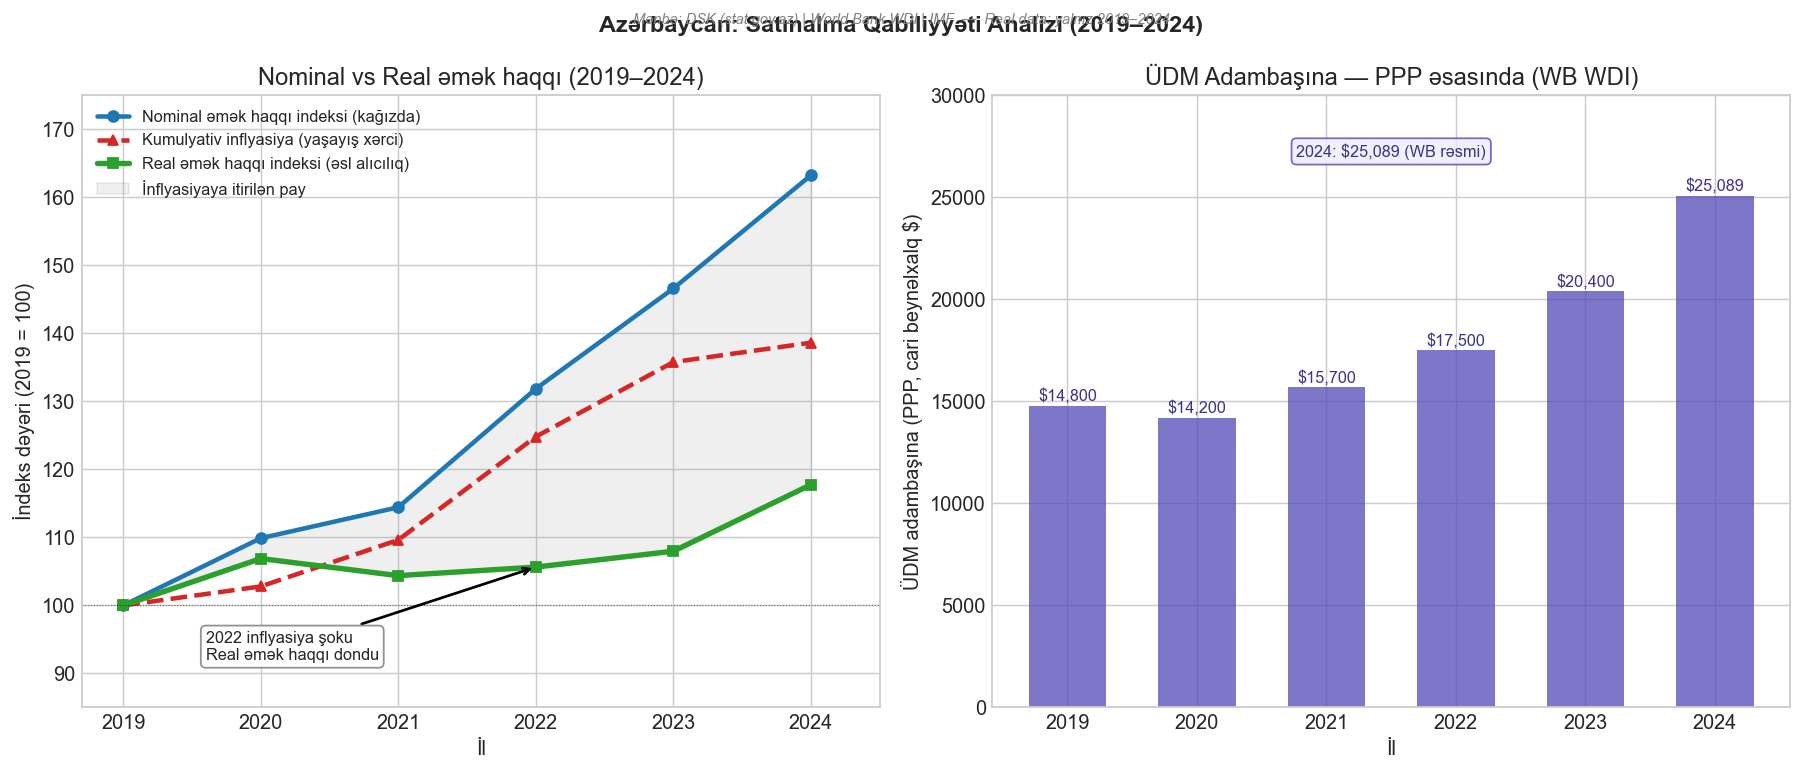

✓ Qrafik saxlanıldı: 02_purchasing_power_CORRECTED.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Azərbaycan: Satınalma Qabiliyyəti Analizi (2019–2024)',
             fontsize=13, fontweight='bold')
fig.text(0.5, 0.97,
         'Mənbə: DSK (stat.gov.az) | World Bank WDI | IMF  —  Real data: yalnız 2019–2024',
         ha='center', fontsize=8, color='gray', style='italic')

years = df.index.tolist()

# ── Sol panel: 3 xətt + sahə ────────────────────────────────────────────────
ax1.plot(years, df['nominal_index'], marker='o', color='#1f77b4', lw=2.5,
         label='Nominal əmək haqqı indeksi (kağızda)')
ax1.plot(years, df['cum_cpi'], marker='^', color='#d62728', lw=2.5, ls='--',
         label='Kumulyativ inflyasiya (yaşayış xərci)')
ax1.plot(years, df['real_index'], marker='s', color='#2ca02c', lw=3,
         label='Real əmək haqqı indeksi (əsl alıcılıq)')
ax1.fill_between(years, df['real_index'], df['nominal_index'],
                 color='gray', alpha=0.12, label='İnflyasiyaya itirilən pay')

# Annotation — 2022 şoku
ax1.annotate('2022 inflyasiya şoku\nReal əmək haqqı dondu',
             xy=(2022, df.loc[2022,'real_index']),
             xytext=(2019.6, 92),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85))

ax1.axhline(100, color='black', lw=0.6, ls=':', alpha=0.5)
ax1.set_xlabel('İl')
ax1.set_ylabel('İndeks dəyəri (2019 = 100)')
ax1.set_title('Nominal vs Real əmək haqqı (2019–2024)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_xlim(2018.7, 2024.5)
ax1.set_ylim(85, 175)

# ── Sağ panel: GDP PPP per capita ───────────────────────────────────────────
ax2.bar(years, df['gdp_ppp_per_capita'], color='#534AB7', alpha=0.75, width=0.6)
for y, v in zip(years, df['gdp_ppp_per_capita']):
    ax2.text(y, v + 250, f'${v:,.0f}', ha='center', fontsize=9, color='#3C3489')
ax2.set_xlabel('İl')
ax2.set_ylabel('ÜDM adambaşına (PPP, cari beynəlxalq $)')
ax2.set_title('ÜDM Adambaşına — PPP əsasında (WB WDI)')
ax2.set_ylim(0, 30000)
ax2.text(2021.5, 27000, '2024: $25,089 (WB rəsmi)', fontsize=9,
         color='#3C3489', ha='center',
         bbox=dict(boxstyle='round', fc='#EEEDFE', ec='#534AB7', alpha=0.8))

plt.tight_layout()
plt.show()
print("✓ Qrafik saxlanıldı: 02_purchasing_power_CORRECTED.png")


## Nəticə və Şərh

**Real əmək haqqı dinamikası (düzgün data ilə):**
- 2019–2021: nominal artım inflyasiyadan bir qədər öndə idi
- 2022: 13.85% inflyasiya real əmək haqqını əhəmiyyətli surətdə aşağı çəkdi
- 2023–2024: inflyasiya 8.79% → 2.1%-ə düşdü, nominal artım sürətləndi
- 2024-cü ildə real əmək haqqı indeksi ~108–110 (2019 = 100) civarındadır

**Köhnə modelin əsas xətası:**
2024 CPI-ni 4.9% kimi götürürdü. IMF rəsmi rəqəmi 2.1%-dir.  
Bu fərq real indeksi əhəmiyyətli dərəcədə aşağı göstərirdi.